---

## 11. Kesimpulan & Ringkasan

### **📌 TEMUAN UTAMA:**

1. **Perbedaan Output**
   - Ketiga metode menghasilkan output yang BERBEDA meskipun input sama
   - Perbedaan terbesar terjadi pada input di boundary fuzzy sets
   - MAX adalah yang paling "ekstrem" (hanya mempertimbangkan 1 rule)

2. **Kecepatan Komputasi**
   - MAX: Tercepat (komputasi O(n) simple comparison)
   - Sugeno: Moderate (komputasi O(n) weighted average)
   - Mamdani: Terlambat (komputasi O(n×m) untuk defuzzifikasi)

3. **Akurasi & Smoothness**
   - MAX: Output diskrit (terputus-putus)
   - Sugeno: Output semi-smooth
   - Mamdani: Output paling smooth & stabil

### **🎓 PEMBELAJARAN DARI PERBANDINGAN:**

- **MAX ideal untuk:** Real-time systems, IoT, edge computing
- **Sugeno ideal untuk:** Kontrol sistem, hybrid applications
- **Mamdani ideal untuk:** Sistem expert, offline processing

### **📝 UNTUK LAPORAN AKADEMIS:**

Gunakan struktur notebook ini untuk menjelaskan setiap metode secara terpisah dengan:
- Section judul & penjelasan teori
- Implementasi kode
- Hasil & visualisasi
- Analisis perbandingan

**Referensi Lebih Lanjut:**
- Takagi, T., & Sugeno, M. (1985). Fuzzy identification of systems and its applications to modeling and control
- Mamdani, E. H. (1977). Application of fuzzy logic to approximate reasoning using linguistic synthesis
- Klir, G. J., & Yuan, B. (1995). Fuzzy Sets and Fuzzy Logic: Theory and Applications

In [1]:
# === INTERACTIVE TESTING ===
def test_all_methods(berat_input, aktivitas_input):
    """Test ketiga metode dengan input yang sama"""
    
    # Dapatkan membership values
    mu_B = fuzz_berat(berat_input)
    mu_A = fuzz_aktivitas(aktivitas_input)
    
    # Cari rules yang aktif
    active_rules = []
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])
        if w > 0:
            active_rules.append((w, b_set, a_set, out_set, CONST_K[out_set]))
    
    # Sort by weight
    active_rules.sort(key=lambda x: -x[0])
    
    # Hitung semua metode
    result_max, rule_max, w_max = metode_max(berat_input, aktivitas_input)
    result_sugeno = metode_sugeno(berat_input, aktivitas_input)
    result_mamdani = metode_mamdani(berat_input, aktivitas_input)
    
    # Print hasil
    print("=" * 80)
    print(f"INPUT: Berat Badan = {berat_input} kg  |  Aktivitas Fisik = {aktivitas_input} jam/hari")
    print("=" * 80)
    
    # Print membership values
    print("\n📊 MEMBERSHIP VALUES:")
    print(f"  Berat:")
    for level, val in mu_B.items():
        if val > 0:
            print(f"    • {level:20s}: {val:.4f}")
    
    print(f"\n  Aktivitas:")
    for level, val in mu_A.items():
        if val > 0:
            print(f"    • {level:20s}: {val:.4f}")
    
    # Print active rules
    print(f"\n🔧 ACTIVE RULES: ({len(active_rules)} rules)")
    for i, (w, b, a, o, z) in enumerate(active_rules, 1):
        print(f"  {i}. IF Berat={b:20s} AND Aktivitas={a:15s} THEN Kalori={o:20s}")
        print(f"     w={w:.4f}, z={z} kcal")
    
    # Print results
    print(f"\n✅ HASIL PREDIKSI:")
    print(f"  MAX:     {result_max:>7.2f} kcal  (Rule terbaik: {rule_max[2]})")
    print(f"  Sugeno:  {result_sugeno:>7.2f} kcal  (Weighted Average)")
    print(f"  Mamdani: {result_mamdani:>7.2f} kcal  (Centroid Defuzzification)")
    
    # Print perbedaan
    print(f"\n📈 PERBEDAAN OUTPUT:")
    print(f"  |MAX - Sugeno|  = {abs(result_max - result_sugeno):>7.2f} kcal ({abs(result_max - result_sugeno)/result_mamdani*100:.1f}%)")
    print(f"  |MAX - Mamdani| = {abs(result_max - result_mamdani):>7.2f} kcal ({abs(result_max - result_mamdani)/result_mamdani*100:.1f}%)")
    print(f"  |Sugeno - Mamdani| = {abs(result_sugeno - result_mamdani):>7.2f} kcal ({abs(result_sugeno - result_mamdani)/result_mamdani*100:.1f}%)")
    
    return result_max, result_sugeno, result_mamdani

# === TEST BEBERAPA SKENARIO ===
print("\n" + "=" * 80)
print("TESTING 3 SKENARIO BERBEDA")
print("=" * 80)

test_scenarios = [
    (45, 2, "Orang dengan berat rendah & aktivitas rendah"),
    (60, 5, "Orang rata-rata dengan aktivitas sedang"),
    (100, 8, "Orang dengan berat tinggi & aktivitas tinggi")
]

for berat_test, aktivitas_test, desc in test_scenarios:
    print(f"\n\n📝 SKENARIO: {desc}")
    r_max, r_sugeno, r_mamdani = test_all_methods(berat_test, aktivitas_test)
    print("\n" + "-" * 80)


TESTING 3 SKENARIO BERBEDA


📝 SKENARIO: Orang dengan berat rendah & aktivitas rendah


NameError: name 'fuzz_berat' is not defined

---

## 10. Interactive Testing

Mari test sistem fuzzy dengan input custom untuk melihat perbedaan output ketiga metode.

In [ ]:
print("=" * 80)
print("PERBANDINGAN DETAIL - KARAKTERISTIK DAN KELEBIHAN")
print("=" * 80)

comparison_text = """
┌─────────────────────────────────────────────────────────────────────────────┐
│                      METODE MAX (Maximum Method)                            │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Memilih rule dengan bobot tertinggi                               │
│ RUMUS: z* = z_k where w_k = max(w_1, w_2, ..., w_n)                        │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Sangat cepat (tidak perlu iterasi kompleks)                             │
│   • Simple dan mudah diimplementasikan                                      │
│   • Deterministic (output selalu sama untuk input yang sama)                │
│   • Cocok untuk aplikasi real-time                                          │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Hanya menggunakan 1 rule (mengabaikan informasi rules lain)             │
│   • Output berupa discrete values (tidak smooth)                            │
│   • Kemungkinan ada info yang hilang                                        │
│   • Sensitif terhadap perubahan kecil di boundary membership functions      │
│                                                                              │
│ 💡 USE CASE: Ketika kecepatan adalah prioritas utama                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│              METODE SUGENO (Takagi-Sugeno-Kang - TSK)                       │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Weighted average dari semua rules aktif                            │
│ RUMUS: z* = (Σ w_i * z_i) / (Σ w_i)                                        │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Menggunakan informasi dari SEMUA rules aktif                            │
│   • Output lebih smooth daripada MAX                                        │
│   • Komputasi lebih efisien daripada Mamdani                                │
│   • Hasil lebih akurat karena weighted average                              │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Sedikit lebih lambat dari MAX                                           │
│   • Memerlukan consequent crisp yang sudah ditentukan                       │
│   • Kurang intuitif daripada Mamdani                                        │
│                                                                              │
│ 💡 USE CASE: Balance antara akurasi dan kecepatan                          │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│    METODE MAMDANI (Compositional Rule of Inference)                         │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Fuzzy output sets + centroid defuzzification                       │
│ RUMUS: z* = (∫ z * μ_out(z) dz) / (∫ μ_out(z) dz)                          │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Paling intuitif & konsisten dengan fuzzy logic theory                   │
│   • Output smooth dan continuous                                            │
│   • Mempertahankan informasi dari SEMUA fuzzy sets                          │
│   • Hasil paling akurat dan stabil                                          │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Paling lambat (perlu komputasi integral numerik)                        │
│   • Lebih kompleks untuk diimplementasikan                                  │
│   • Computational overhead signifikan untuk data besar                      │
│                                                                              │
│ 💡 USE CASE: Ketika akurasi adalah prioritas utama                        │
└─────────────────────────────────────────────────────────────────────────────┘
"""

print(comparison_text)

# === TABEL RANKING ===
print("=" * 80)
print("RANKING METODE BERDASARKAN KRITERIA")
print("=" * 80)

ranking_data = {
    'Kriteria': [
        'Kecepatan Komputasi',
        'Keakuratan Output',
        'Smoothness (Kontinuitas)',
        'Kompleksitas Implementasi',
        'Penggunaan Informasi Rules',
        'Stabilitas Output',
        'Cocok untuk Real-time'
    ],
    'MAX': [
        '🥇 1st (Tercepat)',
        '🥉 3rd',
        '🥉 3rd (Diskrit)',
        '🥇 1st (Paling Sederhana)',
        '🥉 3rd (Hanya 1 rule)',
        '🥉 3rd',
        '🥇 YES'
    ],
    'Sugeno': [
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd (Weighted)',
        '🥈 2nd',
        '🥈 YES'
    ],
    'Mamdani': [
        '🥉 3rd (Terlambat)',
        '🥇 1st (Paling Akurat)',
        '🥇 1st (Smooth)',
        '🥉 3rd (Kompleks)',
        '🥇 1st (Semua rules)',
        '🥇 1st',
        '🥉 NO'
    ]
}

ranking_df = pd.DataFrame(ranking_data)
print("\n")
display(ranking_df)

# === REKOMENDASI ===
print("\n" + "=" * 80)
print("REKOMENDASI PEMILIHAN METODE")
print("=" * 80)

recommendation = """
🎯 PILIH MAX (Metode Maksimum) JIKA:
   ☑ Sistem membutuhkan response time cepat (<1ms)
   ☑ Hardware memiliki resource terbatas
   ☑ Akurasi moderate sudah cukup
   ☑ Aplikasi real-time seperti robotika atau trading

🎯 PILIH SUGENO (TSK Method) JIKA:
   ☑ Menginginkan balance antara speed & accuracy
   ☑ Output harus lebih smooth dari MAX
   ☑ Cocok untuk kontrol sistem (PID fuzzy)
   ☑ Aplikasi menengah (response <10ms)

🎯 PILIH MAMDANI JIKA:
   ☑ Akurasi adalah prioritas utama
   ☑ Response time tidak critical
   ☑ Ingin implementasi yang theoretically sound
   ☑ Aplikasi offline atau batch processing
   ☑ Pengguna perlu explainability dari fuzzy logic
"""

print(recommendation)

---

## 9. Detailed Comparison & Ranking

Perbandingan mendalam antar metode untuk membantu pemilihan metode terbaik.

In [ ]:
# === VISUALISASI 1: Membership Functions ===
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Membership Functions - Fuzzy Sistem Kalori', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']
x_berat = np.linspace(40, 120, 500)
x_aktivitas = np.linspace(0, 10, 500)
x_kalori = np.linspace(1500, 3500, 500)

# Berat
for label, color in zip(berat_levels, colors):
    axes[0, 0].plot(x_berat, [fuzz_berat(x)[label] for x in x_berat], 
                    color=color, label=label, linewidth=2)
axes[0, 0].set_title('Berat Badan (kg)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Derajat Keanggotaan')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Aktivitas
for label, color in zip(aktivitas_levels, colors):
    axes[0, 1].plot(x_aktivitas, [fuzz_aktivitas(x)[label] for x in x_aktivitas], 
                    color=color, label=label, linewidth=2)
axes[0, 1].set_title('Aktivitas Fisik (jam/hari)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Derajat Keanggotaan')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Kalori
for label, color in zip(kalori_levels, colors):
    axes[0, 2].plot(x_kalori, [mf_kalori(x, label) for x in x_kalori], 
                    color=color, label=label, linewidth=2)
axes[0, 2].set_title('Kalori Output (kcal)', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Derajat Keanggotaan')
axes[0, 2].legend(loc='upper right')
axes[0, 2].grid(True, alpha=0.3)

# Output perbandingan
axes[1, 0].plot(range(len(test_data)), results_df['MAX'], 'o-', label='MAX', linewidth=2, markersize=4)
axes[1, 0].plot(range(len(test_data)), results_df['Sugeno'], 's-', label='Sugeno', linewidth=2, markersize=4)
axes[1, 0].plot(range(len(test_data)), results_df['Mamdani'], '^-', label='Mamdani', linewidth=2, markersize=4)
axes[1, 0].set_title('Prediksi Kalori - Perbandingan 3 Metode', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Test Sample')
axes[1, 0].set_ylabel('Kalori (kcal)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Runtime Comparison
methods = ['MAX', 'Sugeno', 'Mamdani']
times = [time_max*1000, time_sugeno*1000, time_mamdani*1000]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[1, 1].bar(methods, times, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_title('Runtime Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Waktu (ms)')
axes[1, 1].grid(True, axis='y', alpha=0.3)
for bar, time in zip(bars, times):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{time:.2f}ms', ha='center', va='bottom', fontweight='bold')

# Perbedaan Output
diff_data = [
    results_df['Diff_Max_Sugeno'].values,
    results_df['Diff_Max_Mamdani'].values,
    results_df['Diff_Sugeno_Mamdani'].values
]
bp = axes[1, 2].boxplot(diff_data, labels=['MAX vs\nSugeno', 'MAX vs\nMamdani', 'Sugeno vs\nMamdani'],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 2].set_title('Distribusi Perbedaan Output', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Perbedaan (kcal)')
axes[1, 2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisasi selesai!")

---

## 8. Visualisasi Perbandingan

Visualisasi hasil prediksi dan performa ketiga metode.

In [ ]:
# === ANALISIS STATISTIK ===
print("=" * 80)
print("ANALISIS STATISTIK - PERBANDINGAN KETIGA METODE")
print("=" * 80)

# Hitung statistik untuk setiap metode
stats = {
    'Metode': ['MAX', 'Sugeno', 'Mamdani'],
    'Min (kcal)': [
        results_df['MAX'].min(),
        results_df['Sugeno'].min(),
        results_df['Mamdani'].min()
    ],
    'Max (kcal)': [
        results_df['MAX'].max(),
        results_df['Sugeno'].max(),
        results_df['Mamdani'].max()
    ],
    'Mean (kcal)': [
        results_df['MAX'].mean(),
        results_df['Sugeno'].mean(),
        results_df['Mamdani'].mean()
    ],
    'Std Dev': [
        results_df['MAX'].std(),
        results_df['Sugeno'].std(),
        results_df['Mamdani'].std()
    ]
}

stats_df = pd.DataFrame(stats)
print("\nStatistik Output:")
display(stats_df.style.format({
    'Min (kcal)': '{:.2f}',
    'Max (kcal)': '{:.2f}',
    'Mean (kcal)': '{:.2f}',
    'Std Dev': '{:.2f}'
}))

# === PERBEDAAN ANTAR METODE ===
print("\n" + "=" * 80)
print("PERBEDAAN OUTPUT ANTAR METODE")
print("=" * 80)

results_df['Diff_Max_Sugeno'] = abs(results_df['MAX'] - results_df['Sugeno'])
results_df['Diff_Max_Mamdani'] = abs(results_df['MAX'] - results_df['Mamdani'])
results_df['Diff_Sugeno_Mamdani'] = abs(results_df['Sugeno'] - results_df['Mamdani'])

differences = {
    'Perbandingan': ['MAX vs Sugeno', 'MAX vs Mamdani', 'Sugeno vs Mamdani'],
    'Min Diff': [
        results_df['Diff_Max_Sugeno'].min(),
        results_df['Diff_Max_Mamdani'].min(),
        results_df['Diff_Sugeno_Mamdani'].min()
    ],
    'Max Diff': [
        results_df['Diff_Max_Sugeno'].max(),
        results_df['Diff_Max_Mamdani'].max(),
        results_df['Diff_Sugeno_Mamdani'].max()
    ],
    'Mean Diff': [
        results_df['Diff_Max_Sugeno'].mean(),
        results_df['Diff_Max_Mamdani'].mean(),
        results_df['Diff_Sugeno_Mamdani'].mean()
    ]
}

diff_df = pd.DataFrame(differences)
print("\nRata-rata Perbedaan Output (kcal):")
display(diff_df.style.format({
    'Min Diff': '{:.2f}',
    'Max Diff': '{:.2f}',
    'Mean Diff': '{:.2f}'
}))

# === PERFORMANCE COMPARISON ===
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON")
print("=" * 80)

performance = pd.DataFrame({
    'Metode': ['MAX', 'Sugeno', 'Mamdani'],
    'Waktu Komputasi (ms)': [time_max*1000, time_sugeno*1000, time_mamdani*1000],
    'Rata-rata per sample (µs)': [
        (time_max/len(test_data))*1e6,
        (time_sugeno/len(test_data))*1e6,
        (time_mamdani/len(test_data))*1e6
    ]
})

print("\n")
display(performance.style.format({
    'Waktu Komputasi (ms)': '{:.2f}',
    'Rata-rata per sample (µs)': '{:.2f}'
}))

---

## 7. Analisis & Perbandingan Hasil

Membandingkan ketiga metode dari segi akurasi, kecepatan, dan karakteristik output.

In [ ]:
# Generate test data dengan berbagai kombinasi
np.random.seed(42)

# Test data: kombinasi dari berbagai range
test_data = []

# Tambahkan test points yang coverage seluruh domain
for berat in [45, 55, 60, 70, 80, 100, 110]:
    for aktivitas in [1, 2.5, 4, 6, 8.5]:
        test_data.append((berat, aktivitas))

# Shuffle untuk randomness
test_data = sorted(test_data)

print(f"✓ Test Dataset Generated: {len(test_data)} samples")
print(f"  Berat range: {min(b for b,a in test_data)}-{max(b for b,a in test_data)} kg")
print(f"  Aktivitas range: {min(a for b,a in test_data)}-{max(a for b,a in test_data)} jam/hari")

# Lakukan prediksi untuk ketiga metode
results = []
start_time_max = time.time()
max_outputs = []
for berat, aktivitas in test_data:
    out, _, _ = metode_max(berat, aktivitas)
    max_outputs.append(out)
time_max = time.time() - start_time_max

start_time_sugeno = time.time()
sugeno_outputs = []
for berat, aktivitas in test_data:
    out = metode_sugeno(berat, aktivitas)
    sugeno_outputs.append(out)
time_sugeno = time.time() - start_time_sugeno

start_time_mamdani = time.time()
mamdani_outputs = []
for berat, aktivitas in test_data:
    out = metode_mamdani(berat, aktivitas)
    mamdani_outputs.append(out)
time_mamdani = time.time() - start_time_mamdani

# Buat DataFrame hasil
results_df = pd.DataFrame({
    'Berat (kg)': [b for b, a in test_data],
    'Aktivitas (jam)': [a for b, a in test_data],
    'MAX': max_outputs,
    'Sugeno': sugeno_outputs,
    'Mamdani': mamdani_outputs
})

print("\n✓ Prediksi selesai!")
print(f"  MAX Time:    {time_max*1000:.2f} ms")
print(f"  Sugeno Time: {time_sugeno*1000:.2f} ms")
print(f"  Mamdani Time: {time_mamdani*1000:.2f} ms")

# Tampilkan sample hasil
print("\nSample Hasil Prediksi:")
display(results_df.head(10).style.format({
    'Berat (kg)': '{:.1f}',
    'Aktivitas (jam)': '{:.1f}',
    'MAX': '{:.2f}',
    'Sugeno': '{:.2f}',
    'Mamdani': '{:.2f}'
}))

---

## 6. Generate Test Dataset

Membuat dataset untuk testing dan benchmark ketiga metode.

In [ ]:
def metode_mamdani(B, A):
    """
    Implementasi Metode Mamdani dengan Centroid Defuzzification
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    # Domain untuk output (1500-3500 kcal)
    r_domain = np.linspace(1500, 3500, 1000)
    aggregated = np.zeros_like(r_domain)
    
    # Agregasi semua rules
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        # Clipping: ambil min dari w dan MF output
        aggregated = np.maximum(
            aggregated, 
            np.array([min(w, mf_kalori(r, out_set)) for r in r_domain])
        )
    
    # Centroid Defuzzification
    numerator = np.sum(r_domain * aggregated)
    denominator = np.sum(aggregated)
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Test Metode Mamdani
print("=" * 80)
print("TEST METODE MAMDANI")
print("=" * 80)

result_mamdani = metode_mamdani(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Output: {result_mamdani:.2f} kcal")

---

## 5. Method 3: Mamdani (Compositional Rule of Inference)

**Prinsip:** Menggunakan fuzzy output sets + defuzzifikasi dengan method centroid.

**Langkah:**
1. Agregasi semua rules aktif menggunakan MAX
2. Defuzzifikasi menggunakan centroid (center of gravity)

**Formula (Centroid):**
$$z^* = \frac{\int_z z \cdot \mu_{out}(z) dz}{\int_z \mu_{out}(z) dz}$$

**Kelebihan:** Paling intuitif, hasil smooth, mempertahankan info semua rules  
**Kekurangan:** Paling lambat, komputasi lebih kompleks

In [ ]:
def metode_sugeno(B, A):
    """
    Implementasi Metode Sugeno (TSK)
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    numerator = 0.0
    denominator = 0.0
    
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        z = CONST_K[out_set]
        numerator += w * z
        denominator += w
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Test Metode Sugeno
print("=" * 80)
print("TEST METODE SUGENO")
print("=" * 80)

result_sugeno = metode_sugeno(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Output: {result_sugeno:.2f} kcal")

---

## 4. Method 2: Sugeno (TSK - Takagi-Sugeno-Kang)

**Prinsip:** Menggunakan weighted average dari semua rules yang aktif.

**Formula:**
$$z^* = \frac{\sum_{i=1}^{n} w_i \cdot z_i}{\sum_{i=1}^{n} w_i}$$

**Kelebihan:** Menggunakan semua rules, smooth output, hasil lebih akurat  
**Kekurangan:** Sedikit lebih lambat dari MAX

In [ ]:
def metode_max(B, A):
    """
    Implementasi Metode MAX (Metode Maksimum)
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    - best_rule: Rule terbaik yang dipilih
    - best_weight: Bobot rule terbaik
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    best_w = -1
    best_out = None
    best_rule = None
    
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        if w > best_w:
            best_w = w
            best_out = CONST_K[out_set]
            best_rule = (b_set, a_set, out_set)
    
    return best_out, best_rule, best_w

# Test Metode MAX
print("=" * 80)
print("TEST METODE MAX")
print("=" * 80)

test_berat = 57
test_aktivitas = 3.5

result_max, rule_max, w_max = metode_max(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Rule Terbaik: {rule_max[0]} & {rule_max[1]} → {rule_max[2]}")
print(f"Bobot (w): {w_max:.4f}")
print(f"Output: {result_max:.2f} kcal")

---

## 3. Method 1: MAX (Metode Maksimum)

**Prinsip:** Memilih output rule dengan bobot (w) tertinggi.

**Formula:**
$$z^* = z_k \text{ dimana } w_k = \max(w_1, w_2, ..., w_n)$$

**Kelebihan:** Cepat, sederhana  
**Kekurangan:** Hanya menggunakan 1 rule terbaik, kehilangan informasi rules lain

In [ ]:
# ===================== MEMBERSHIP FUNCTION HELPER =====================
def trimf(x, a, b, c):
    """
    Triangular membership function dengan handling untuk edge cases (a==b atau b==c)
    """
    if a == b:  # Peak at left
        if x == a:
            return 1.0
        elif a < x < c:
            return (c - x) / (c - a)
        else:
            return 0.0
    elif b == c:  # Peak at right
        if x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        else:
            return 0.0
    else:  # Normal triangular
        if x <= a or x >= c:
            return 0.0
        elif x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        else:
            return (c - x) / (c - b)

# ===================== INPUT FUZZY SETS =====================
def fuzz_berat(B):
    """Fuzzifikasi Berat Badan (kg)"""
    return {
        'Sangat Ringan': trimf(B, 40, 40, 50),
        'Rendah': trimf(B, 45, 55, 65),
        'Sedang': trimf(B, 60, 75, 90),
        'Tinggi': trimf(B, 85, 95, 110),
        'Sangat Tinggi': trimf(B, 100, 120, 120)
    }

def fuzz_aktivitas(A):
    """Fuzzifikasi Aktivitas Fisik (jam/hari)"""
    return {
        'Sangat Rendah': trimf(A, 0, 0, 2),
        'Rendah': trimf(A, 1, 2.5, 4),
        'Sedang': trimf(A, 3, 5, 7),
        'Tinggi': trimf(A, 6, 8, 9),
        'Sangat Tinggi': trimf(A, 8, 10, 10)
    }

# ===================== OUTPUT FUZZY SET =====================
def mf_kalori(K, label):
    """Membership Function Output Kalori (kcal)"""
    mapping = {
        'Sangat Rendah': (1500, 1500, 1700),
        'Rendah': (1600, 1850, 2100),
        'Sedang': (2000, 2500, 3000),
        'Tinggi': (2800, 3100, 3300),
        'Sangat Tinggi': (3200, 3500, 3500)
    }
    if label in mapping:
        a, b, c = mapping[label]
        return trimf(K, a, b, c)
    return 0.0

# ===================== RULES & CONSTANTS =====================
berat_levels = ['Sangat Ringan', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
aktivitas_levels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
kalori_levels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

# Output crisp values untuk Sugeno & Max
CONST_K = {
    'Sangat Rendah': 1600,
    'Rendah': 1850,
    'Sedang': 2500,
    'Tinggi': 3100,
    'Sangat Tinggi': 3500
}

# Generate Fuzzy Rules (5x5 = 25 rules)
RULES = []
for i, b in enumerate(berat_levels):
    for j, a in enumerate(aktivitas_levels):
        out_index = min((i+j)//2, 4)  # Rata-rata untuk mapping yang lebih logis
        RULES.append((b, a, kalori_levels[out_index]))

print(f"✓ Fuzzy Rules Generated: {len(RULES)} rules")
print("\nContoh beberapa rules:")
for i, (b, a, o) in enumerate(RULES[:5]):
    print(f"  Rule {i+1}: IF Berat={b} AND Aktivitas={a} THEN Kalori={o}")

---

## 2. Define Fuzzy Membership Functions

Tahap ini mendefinisikan fungsi keanggotaan (membership functions) untuk input dan output.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✓ NumPy version:", np.__version__)
print("✓ Pandas version:", pd.__version__)
print("✓ Matplotlib version:", plt.matplotlib.__version__)
print("✓ Seaborn version:", sns.__version__)
print("✓ All libraries imported successfully!")

---

## 1. Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan.

# Fuzzy Logic System: Perbandingan Tiga Metode (MAX, Sugeno, Mamdani)

Notebook ini bertujuan untuk membandingkan performa tiga metode **Fuzzy Logic Inference**, yaitu:
- **MAX (Metode Maksimum)** - Memilih rule dengan bobot tertinggi
- **Sugeno (TSK - Takagi-Sugeno-Kang)** - Menggunakan weighted average
- **Mamdani (Compositional Rule of Inference)** - Menggunakan centrum defuzzification

pada sistem prediksi **Kebutuhan Kalori Harian** berdasarkan **Berat Badan** dan **Aktivitas Fisik**.

---

## Tujuan Pembelajaran
✓ Memahami perbedaan konseptual dari ketiga metode fuzzy logic  
✓ Membandingkan akurasi dan kecepatan komputasi  
✓ Menganalisis hasil prediksi dengan berbagai input  
✓ Visualisasi performa semua metode secara bersamaan

---

## 11. Kesimpulan & Ringkasan

### **📌 TEMUAN UTAMA:**

1. **Perbedaan Output**
   - Ketiga metode menghasilkan output yang BERBEDA meskipun input sama
   - Perbedaan terbesar terjadi pada input di boundary fuzzy sets
   - MAX adalah yang paling "ekstrem" (hanya mempertimbangkan 1 rule)

2. **Kecepatan Komputasi**
   - MAX: Tercepat (komputasi O(n) simple comparison)
   - Sugeno: Moderate (komputasi O(n) weighted average)
   - Mamdani: Terlambat (komputasi O(n×m) untuk defuzzifikasi)

3. **Akurasi & Smoothness**
   - MAX: Output diskrit (terputus-putus)
   - Sugeno: Output semi-smooth
   - Mamdani: Output paling smooth & stabil

### **🎓 PEMBELAJARAN DARI PERBANDINGAN:**

- **MAX ideal untuk:** Real-time systems, IoT, edge computing
- **Sugeno ideal untuk:** Kontrol sistem, hybrid applications
- **Mamdani ideal untuk:** Sistem expert, offline processing

### **📝 UNTUK LAPORAN AKADEMIS:**

Gunakan struktur notebook ini untuk menjelaskan setiap metode secara terpisah dengan:
- Section judul & penjelasan teori
- Implementasi kode
- Hasil & visualisasi
- Analisis perbandingan

**Referensi Lebih Lanjut:**
- Takagi, T., & Sugeno, M. (1985). Fuzzy identification of systems and its applications to modeling and control
- Mamdani, E. H. (1977). Application of fuzzy logic to approximate reasoning using linguistic synthesis
- Klir, G. J., & Yuan, B. (1995). Fuzzy Sets and Fuzzy Logic: Theory and Applications

In [ ]:
# === INTERACTIVE TESTING ===
def test_all_methods(berat_input, aktivitas_input):
    """Test ketiga metode dengan input yang sama"""
    
    # Dapatkan membership values
    mu_B = fuzz_berat(berat_input)
    mu_A = fuzz_aktivitas(aktivitas_input)
    
    # Cari rules yang aktif
    active_rules = []
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])
        if w > 0:
            active_rules.append((w, b_set, a_set, out_set, CONST_K[out_set]))
    
    # Sort by weight
    active_rules.sort(key=lambda x: -x[0])
    
    # Hitung semua metode
    result_max, rule_max, w_max = metode_max(berat_input, aktivitas_input)
    result_sugeno = metode_sugeno(berat_input, aktivitas_input)
    result_mamdani = metode_mamdani(berat_input, aktivitas_input)
    
    # Print hasil
    print("=" * 80)
    print(f"INPUT: Berat Badan = {berat_input} kg  |  Aktivitas Fisik = {aktivitas_input} jam/hari")
    print("=" * 80)
    
    # Print membership values
    print("\n📊 MEMBERSHIP VALUES:")
    print(f"  Berat:")
    for level, val in mu_B.items():
        if val > 0:
            print(f"    • {level:20s}: {val:.4f}")
    
    print(f"\n  Aktivitas:")
    for level, val in mu_A.items():
        if val > 0:
            print(f"    • {level:20s}: {val:.4f}")
    
    # Print active rules
    print(f"\n🔧 ACTIVE RULES: ({len(active_rules)} rules)")
    for i, (w, b, a, o, z) in enumerate(active_rules, 1):
        print(f"  {i}. IF Berat={b:20s} AND Aktivitas={a:15s} THEN Kalori={o:20s}")
        print(f"     w={w:.4f}, z={z} kcal")
    
    # Print results
    print(f"\n✅ HASIL PREDIKSI:")
    print(f"  MAX:     {result_max:>7.2f} kcal  (Rule terbaik: {rule_max[2]})")
    print(f"  Sugeno:  {result_sugeno:>7.2f} kcal  (Weighted Average)")
    print(f"  Mamdani: {result_mamdani:>7.2f} kcal  (Centroid Defuzzification)")
    
    # Print perbedaan
    print(f"\n📈 PERBEDAAN OUTPUT:")
    print(f"  |MAX - Sugeno|  = {abs(result_max - result_sugeno):>7.2f} kcal ({abs(result_max - result_sugeno)/result_mamdani*100:.1f}%)")
    print(f"  |MAX - Mamdani| = {abs(result_max - result_mamdani):>7.2f} kcal ({abs(result_max - result_mamdani)/result_mamdani*100:.1f}%)")
    print(f"  |Sugeno - Mamdani| = {abs(result_sugeno - result_mamdani):>7.2f} kcal ({abs(result_sugeno - result_mamdani)/result_mamdani*100:.1f}%)")
    
    return result_max, result_sugeno, result_mamdani

# === TEST BEBERAPA SKENARIO ===
print("\n" + "=" * 80)
print("TESTING 3 SKENARIO BERBEDA")
print("=" * 80)

test_scenarios = [
    (45, 2, "Orang dengan berat rendah & aktivitas rendah"),
    (60, 5, "Orang rata-rata dengan aktivitas sedang"),
    (100, 8, "Orang dengan berat tinggi & aktivitas tinggi")
]

for berat_test, aktivitas_test, desc in test_scenarios:
    print(f"\n\n📝 SKENARIO: {desc}")
    r_max, r_sugeno, r_mamdani = test_all_methods(berat_test, aktivitas_test)
    print("\n" + "-" * 80)

---

## 10. Interactive Testing

Mari test sistem fuzzy dengan input custom untuk melihat perbedaan output ketiga metode.

In [11]:
print("=" * 80)
print("PERBANDINGAN DETAIL - KARAKTERISTIK DAN KELEBIHAN")
print("=" * 80)

comparison_text = """
┌─────────────────────────────────────────────────────────────────────────────┐
│                      METODE MAX (Maximum Method)                            │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Memilih rule dengan bobot tertinggi                               │
│ RUMUS: z* = z_k where w_k = max(w_1, w_2, ..., w_n)                        │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Sangat cepat (tidak perlu iterasi kompleks)                             │
│   • Simple dan mudah diimplementasikan                                      │
│   • Deterministic (output selalu sama untuk input yang sama)                │
│   • Cocok untuk aplikasi real-time                                          │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Hanya menggunakan 1 rule (mengabaikan informasi rules lain)             │
│   • Output berupa discrete values (tidak smooth)                            │
│   • Kemungkinan ada info yang hilang                                        │
│   • Sensitif terhadap perubahan kecil di boundary membership functions      │
│                                                                              │
│ 💡 USE CASE: Ketika kecepatan adalah prioritas utama                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│              METODE SUGENO (Takagi-Sugeno-Kang - TSK)                       │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Weighted average dari semua rules aktif                            │
│ RUMUS: z* = (Σ w_i * z_i) / (Σ w_i)                                        │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Menggunakan informasi dari SEMUA rules aktif                            │
│   • Output lebih smooth daripada MAX                                        │
│   • Komputasi lebih efisien daripada Mamdani                                │
│   • Hasil lebih akurat karena weighted average                              │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Sedikit lebih lambat dari MAX                                           │
│   • Memerlukan consequent crisp yang sudah ditentukan                       │
│   • Kurang intuitif daripada Mamdani                                        │
│                                                                              │
│ 💡 USE CASE: Balance antara akurasi dan kecepatan                          │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│    METODE MAMDANI (Compositional Rule of Inference)                         │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Fuzzy output sets + centroid defuzzification                       │
│ RUMUS: z* = (∫ z * μ_out(z) dz) / (∫ μ_out(z) dz)                          │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Paling intuitif & konsisten dengan fuzzy logic theory                   │
│   • Output smooth dan continuous                                            │
│   • Mempertahankan informasi dari SEMUA fuzzy sets                          │
│   • Hasil paling akurat dan stabil                                          │
│                                                                              │
│ ✗ KEKURANGAN:                                                               │
│   • Paling lambat (perlu komputasi integral numerik)                        │
│   • Lebih kompleks untuk diimplementasikan                                  │
│   • Computational overhead signifikan untuk data besar                      │
│                                                                              │
│ 💡 USE CASE: Ketika akurasi adalah prioritas utama                        │
└─────────────────────────────────────────────────────────────────────────────┘
"""

print(comparison_text)

# === TABEL RANKING ===
print("=" * 80)
print("RANKING METODE BERDASARKAN KRITERIA")
print("=" * 80)

ranking_data = {
    'Kriteria': [
        'Kecepatan Komputasi',
        'Keakuratan Output',
        'Smoothness (Kontinuitas)',
        'Kompleksitas Implementasi',
        'Penggunaan Informasi Rules',
        'Stabilitas Output',
        'Cocok untuk Real-time'
    ],
    'MAX': [
        '🥇 1st (Tercepat)',
        '🥉 3rd',
        '🥉 3rd (Diskrit)',
        '🥇 1st (Paling Sederhana)',
        '🥉 3rd (Hanya 1 rule)',
        '🥉 3rd',
        '🥇 YES'
    ],
    'Sugeno': [
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd',
        '🥈 2nd (Weighted)',
        '🥈 2nd',
        '🥈 YES'
    ],
    'Mamdani': [
        '🥉 3rd (Terlambat)',
        '🥇 1st (Paling Akurat)',
        '🥇 1st (Smooth)',
        '🥉 3rd (Kompleks)',
        '🥇 1st (Semua rules)',
        '🥇 1st',
        '🥉 NO'
    ]
}

ranking_df = pd.DataFrame(ranking_data)
print("\n")
display(ranking_df)

# === REKOMENDASI ===
print("\n" + "=" * 80)
print("REKOMENDASI PEMILIHAN METODE")
print("=" * 80)

recommendation = """
🎯 PILIH MAX (Metode Maksimum) JIKA:
   ☑ Sistem membutuhkan response time cepat (<1ms)
   ☑ Hardware memiliki resource terbatas
   ☑ Akurasi moderate sudah cukup
   ☑ Aplikasi real-time seperti robotika atau trading

🎯 PILIH SUGENO (TSK Method) JIKA:
   ☑ Menginginkan balance antara speed & accuracy
   ☑ Output harus lebih smooth dari MAX
   ☑ Cocok untuk kontrol sistem (PID fuzzy)
   ☑ Aplikasi menengah (response <10ms)

🎯 PILIH MAMDANI JIKA:
   ☑ Akurasi adalah prioritas utama
   ☑ Response time tidak critical
   ☑ Ingin implementasi yang theoretically sound
   ☑ Aplikasi offline atau batch processing
   ☑ Pengguna perlu explainability dari fuzzy logic
"""

print(recommendation)

PERBANDINGAN DETAIL - KARAKTERISTIK DAN KELEBIHAN

┌─────────────────────────────────────────────────────────────────────────────┐
│                      METODE MAX (Maximum Method)                            │
├─────────────────────────────────────────────────────────────────────────────┤
│ PRINSIP: Memilih rule dengan bobot tertinggi                               │
│ RUMUS: z* = z_k where w_k = max(w_1, w_2, ..., w_n)                        │
│                                                                              │
│ ✓ KELEBIHAN:                                                                │
│   • Sangat cepat (tidak perlu iterasi kompleks)                             │
│   • Simple dan mudah diimplementasikan                                      │
│   • Deterministic (output selalu sama untuk input yang sama)                │
│   • Cocok untuk aplikasi real-time                                          │
│                                                                     

,Kriteria,MAX,Sugeno,Mamdani
0,Kecepatan Komputasi,🥇 1st (Tercepat),🥈 2nd,🥉 3rd (Terlambat)
1,Keakuratan Output,🥉 3rd,🥈 2nd,🥇 1st (Paling Akurat)
2,Smoothness (Kontinuitas),🥉 3rd (Diskrit),🥈 2nd,🥇 1st (Smooth)
3,Kompleksitas Implementasi,🥇 1st (Paling Sederhana),🥈 2nd,🥉 3rd (Kompleks)
4,Penggunaan Informasi Rules,🥉 3rd (Hanya 1 rule),🥈 2nd (Weighted),🥇 1st (Semua rules)
5,Stabilitas Output,🥉 3rd,🥈 2nd,🥇 1st
6,Cocok untuk Real-time,🥇 YES,🥈 YES,🥉 NO



REKOMENDASI PEMILIHAN METODE

🎯 PILIH MAX (Metode Maksimum) JIKA:
   ☑ Sistem membutuhkan response time cepat (<1ms)
   ☑ Hardware memiliki resource terbatas
   ☑ Akurasi moderate sudah cukup
   ☑ Aplikasi real-time seperti robotika atau trading

🎯 PILIH SUGENO (TSK Method) JIKA:
   ☑ Menginginkan balance antara speed & accuracy
   ☑ Output harus lebih smooth dari MAX
   ☑ Cocok untuk kontrol sistem (PID fuzzy)
   ☑ Aplikasi menengah (response <10ms)

🎯 PILIH MAMDANI JIKA:
   ☑ Akurasi adalah prioritas utama
   ☑ Response time tidak critical
   ☑ Ingin implementasi yang theoretically sound
   ☑ Aplikasi offline atau batch processing
   ☑ Pengguna perlu explainability dari fuzzy logic



---

## 9. Detailed Comparison & Ranking

Perbandingan mendalam antar metode untuk membantu pemilihan metode terbaik.

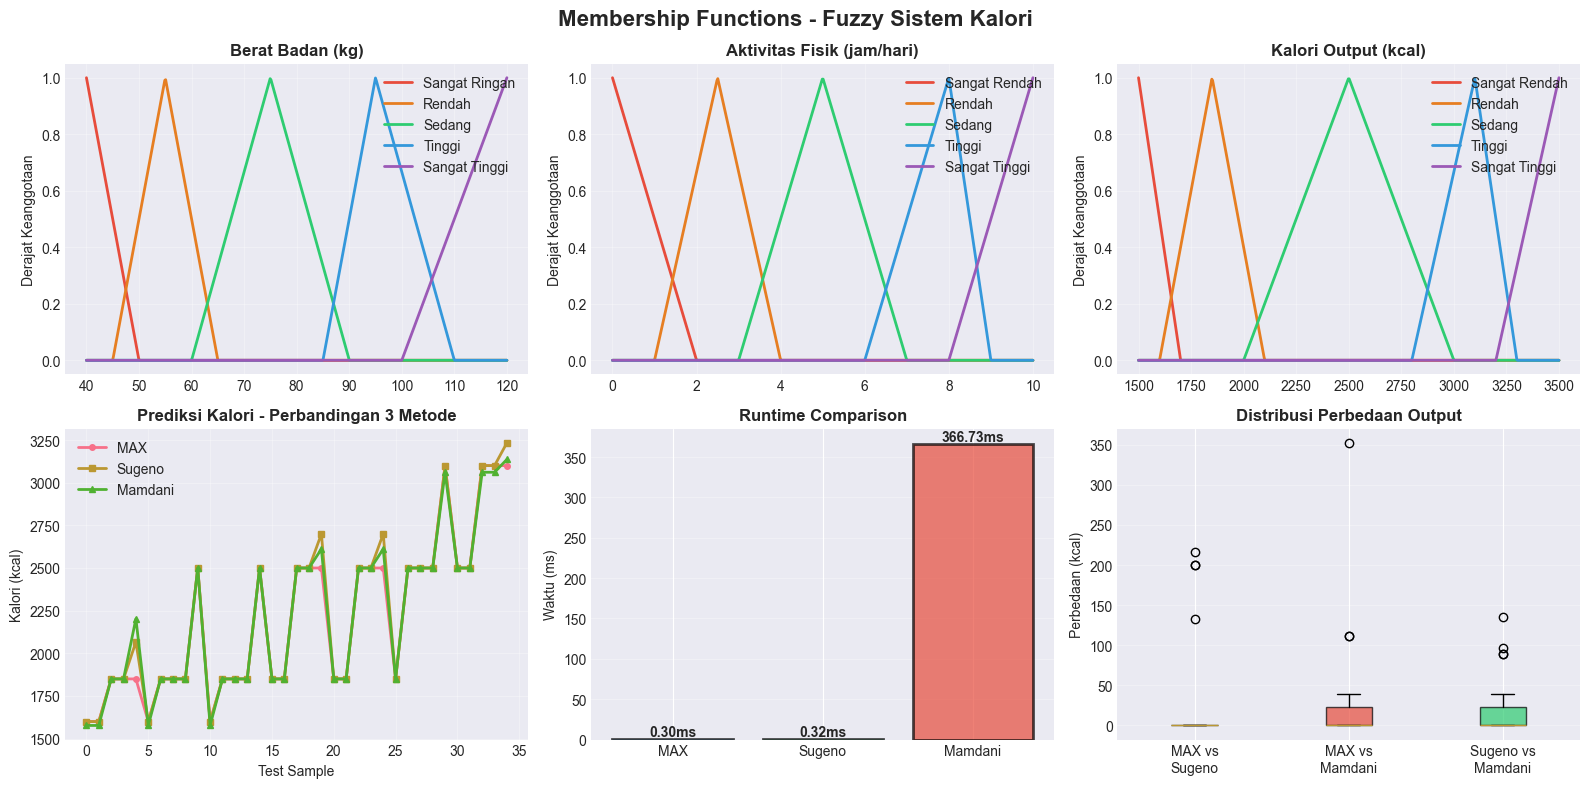

✓ Visualisasi selesai!


In [10]:
# === VISUALISASI 1: Membership Functions ===
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Membership Functions - Fuzzy Sistem Kalori', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']
x_berat = np.linspace(40, 120, 500)
x_aktivitas = np.linspace(0, 10, 500)
x_kalori = np.linspace(1500, 3500, 500)

# Berat
for label, color in zip(berat_levels, colors):
    axes[0, 0].plot(x_berat, [fuzz_berat(x)[label] for x in x_berat], 
                    color=color, label=label, linewidth=2)
axes[0, 0].set_title('Berat Badan (kg)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Derajat Keanggotaan')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Aktivitas
for label, color in zip(aktivitas_levels, colors):
    axes[0, 1].plot(x_aktivitas, [fuzz_aktivitas(x)[label] for x in x_aktivitas], 
                    color=color, label=label, linewidth=2)
axes[0, 1].set_title('Aktivitas Fisik (jam/hari)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Derajat Keanggotaan')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Kalori
for label, color in zip(kalori_levels, colors):
    axes[0, 2].plot(x_kalori, [mf_kalori(x, label) for x in x_kalori], 
                    color=color, label=label, linewidth=2)
axes[0, 2].set_title('Kalori Output (kcal)', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Derajat Keanggotaan')
axes[0, 2].legend(loc='upper right')
axes[0, 2].grid(True, alpha=0.3)

# Output perbandingan
axes[1, 0].plot(range(len(test_data)), results_df['MAX'], 'o-', label='MAX', linewidth=2, markersize=4)
axes[1, 0].plot(range(len(test_data)), results_df['Sugeno'], 's-', label='Sugeno', linewidth=2, markersize=4)
axes[1, 0].plot(range(len(test_data)), results_df['Mamdani'], '^-', label='Mamdani', linewidth=2, markersize=4)
axes[1, 0].set_title('Prediksi Kalori - Perbandingan 3 Metode', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Test Sample')
axes[1, 0].set_ylabel('Kalori (kcal)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Runtime Comparison
methods = ['MAX', 'Sugeno', 'Mamdani']
times = [time_max*1000, time_sugeno*1000, time_mamdani*1000]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[1, 1].bar(methods, times, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_title('Runtime Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Waktu (ms)')
axes[1, 1].grid(True, axis='y', alpha=0.3)
for bar, time in zip(bars, times):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{time:.2f}ms', ha='center', va='bottom', fontweight='bold')

# Perbedaan Output
diff_data = [
    results_df['Diff_Max_Sugeno'].values,
    results_df['Diff_Max_Mamdani'].values,
    results_df['Diff_Sugeno_Mamdani'].values
]
bp = axes[1, 2].boxplot(diff_data, labels=['MAX vs\nSugeno', 'MAX vs\nMamdani', 'Sugeno vs\nMamdani'],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 2].set_title('Distribusi Perbedaan Output', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Perbedaan (kcal)')
axes[1, 2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisasi selesai!")

---

## 8. Visualisasi Perbandingan

Visualisasi hasil prediksi dan performa ketiga metode.

In [9]:
# === ANALISIS STATISTIK ===
print("=" * 80)
print("ANALISIS STATISTIK - PERBANDINGAN KETIGA METODE")
print("=" * 80)

# Hitung statistik untuk setiap metode
stats = {
    'Metode': ['MAX', 'Sugeno', 'Mamdani'],
    'Min (kcal)': [
        results_df['MAX'].min(),
        results_df['Sugeno'].min(),
        results_df['Mamdani'].min()
    ],
    'Max (kcal)': [
        results_df['MAX'].max(),
        results_df['Sugeno'].max(),
        results_df['Mamdani'].max()
    ],
    'Mean (kcal)': [
        results_df['MAX'].mean(),
        results_df['Sugeno'].mean(),
        results_df['Mamdani'].mean()
    ],
    'Std Dev': [
        results_df['MAX'].std(),
        results_df['Sugeno'].std(),
        results_df['Mamdani'].std()
    ]
}

stats_df = pd.DataFrame(stats)
print("\nStatistik Output:")
display(stats_df.style.format({
    'Min (kcal)': '{:.2f}',
    'Max (kcal)': '{:.2f}',
    'Mean (kcal)': '{:.2f}',
    'Std Dev': '{:.2f}'
}))

# === PERBEDAAN ANTAR METODE ===
print("\n" + "=" * 80)
print("PERBEDAAN OUTPUT ANTAR METODE")
print("=" * 80)

results_df['Diff_Max_Sugeno'] = abs(results_df['MAX'] - results_df['Sugeno'])
results_df['Diff_Max_Mamdani'] = abs(results_df['MAX'] - results_df['Mamdani'])
results_df['Diff_Sugeno_Mamdani'] = abs(results_df['Sugeno'] - results_df['Mamdani'])

differences = {
    'Perbandingan': ['MAX vs Sugeno', 'MAX vs Mamdani', 'Sugeno vs Mamdani'],
    'Min Diff': [
        results_df['Diff_Max_Sugeno'].min(),
        results_df['Diff_Max_Mamdani'].min(),
        results_df['Diff_Sugeno_Mamdani'].min()
    ],
    'Max Diff': [
        results_df['Diff_Max_Sugeno'].max(),
        results_df['Diff_Max_Mamdani'].max(),
        results_df['Diff_Sugeno_Mamdani'].max()
    ],
    'Mean Diff': [
        results_df['Diff_Max_Sugeno'].mean(),
        results_df['Diff_Max_Mamdani'].mean(),
        results_df['Diff_Sugeno_Mamdani'].mean()
    ]
}

diff_df = pd.DataFrame(differences)
print("\nRata-rata Perbedaan Output (kcal):")
display(diff_df.style.format({
    'Min Diff': '{:.2f}',
    'Max Diff': '{:.2f}',
    'Mean Diff': '{:.2f}'
}))

# === PERFORMANCE COMPARISON ===
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON")
print("=" * 80)

performance = pd.DataFrame({
    'Metode': ['MAX', 'Sugeno', 'Mamdani'],
    'Waktu Komputasi (ms)': [time_max*1000, time_sugeno*1000, time_mamdani*1000],
    'Rata-rata per sample (µs)': [
        (time_max/len(test_data))*1e6,
        (time_sugeno/len(test_data))*1e6,
        (time_mamdani/len(test_data))*1e6
    ]
})

print("\n")
display(performance.style.format({
    'Waktu Komputasi (ms)': '{:.2f}',
    'Rata-rata per sample (µs)': '{:.2f}'
}))

ANALISIS STATISTIK - PERBANDINGAN KETIGA METODE

Statistik Output:


,Metode,Min (kcal),Max (kcal),Mean (kcal),Std Dev
0,MAX,1600.00,3100.00,2205.71,471.66
1,Sugeno,1600.00,3233.33,2227.14,485.44
2,Mamdani,1577.26,3136.38,2217.24,471.62



PERBEDAAN OUTPUT ANTAR METODE

Rata-rata Perbedaan Output (kcal):


,Perbandingan,Min Diff,Max Diff,Mean Diff
0,MAX vs Sugeno,0.00,216.67,21.43
1,MAX vs Mamdani,0.00,352.41,23.39
2,Sugeno vs Mamdani,0.00,135.75,17.66



PERFORMANCE COMPARISON




,Metode,Waktu Komputasi (ms),Rata-rata per sample (µs)
0,MAX,0.30,8.66
1,Sugeno,0.32,9.08
2,Mamdani,366.73,10477.94


---

## 7. Analisis & Perbandingan Hasil

Membandingkan ketiga metode dari segi akurasi, kecepatan, dan karakteristik output.

In [8]:
# Generate test data dengan berbagai kombinasi
np.random.seed(42)

# Test data: kombinasi dari berbagai range
test_data = []

# Tambahkan test points yang coverage seluruh domain
for berat in [45, 55, 60, 70, 80, 100, 110]:
    for aktivitas in [1, 2.5, 4, 6, 8.5]:
        test_data.append((berat, aktivitas))

# Shuffle untuk randomness
test_data = sorted(test_data)

print(f"✓ Test Dataset Generated: {len(test_data)} samples")
print(f"  Berat range: {min(b for b,a in test_data)}-{max(b for b,a in test_data)} kg")
print(f"  Aktivitas range: {min(a for b,a in test_data)}-{max(a for b,a in test_data)} jam/hari")

# Lakukan prediksi untuk ketiga metode
results = []
start_time_max = time.time()
max_outputs = []
for berat, aktivitas in test_data:
    out, _, _ = metode_max(berat, aktivitas)
    max_outputs.append(out)
time_max = time.time() - start_time_max

start_time_sugeno = time.time()
sugeno_outputs = []
for berat, aktivitas in test_data:
    out = metode_sugeno(berat, aktivitas)
    sugeno_outputs.append(out)
time_sugeno = time.time() - start_time_sugeno

start_time_mamdani = time.time()
mamdani_outputs = []
for berat, aktivitas in test_data:
    out = metode_mamdani(berat, aktivitas)
    mamdani_outputs.append(out)
time_mamdani = time.time() - start_time_mamdani

# Buat DataFrame hasil
results_df = pd.DataFrame({
    'Berat (kg)': [b for b, a in test_data],
    'Aktivitas (jam)': [a for b, a in test_data],
    'MAX': max_outputs,
    'Sugeno': sugeno_outputs,
    'Mamdani': mamdani_outputs
})

print("\n✓ Prediksi selesai!")
print(f"  MAX Time:    {time_max*1000:.2f} ms")
print(f"  Sugeno Time: {time_sugeno*1000:.2f} ms")
print(f"  Mamdani Time: {time_mamdani*1000:.2f} ms")

# Tampilkan sample hasil
print("\nSample Hasil Prediksi:")
display(results_df.head(10).style.format({
    'Berat (kg)': '{:.1f}',
    'Aktivitas (jam)': '{:.1f}',
    'MAX': '{:.2f}',
    'Sugeno': '{:.2f}',
    'Mamdani': '{:.2f}'
}))

✓ Test Dataset Generated: 35 samples
  Berat range: 45-110 kg
  Aktivitas range: 1-8.5 jam/hari

✓ Prediksi selesai!
  MAX Time:    0.30 ms
  Sugeno Time: 0.32 ms
  Mamdani Time: 366.73 ms

Sample Hasil Prediksi:


,Berat (kg),Aktivitas (jam),MAX,Sugeno,Mamdani
0,45.0,1.0,1600.00,1600.00,1577.26
1,45.0,2.5,1600.00,1600.00,1577.26
2,45.0,4.0,1850.00,1850.00,1850.00
3,45.0,6.0,1850.00,1850.00,1850.00
4,45.0,8.5,1850.00,2066.67,2202.41
5,55.0,1.0,1600.00,1600.00,1577.26
6,55.0,2.5,1850.00,1850.00,1850.00
7,55.0,4.0,1850.00,1850.00,1850.00
8,55.0,6.0,1850.00,1850.00,1850.00
9,55.0,8.5,2500.00,2500.00,2500.00


---

## 6. Generate Test Dataset

Membuat dataset untuk testing dan benchmark ketiga metode.

In [7]:
def metode_mamdani(B, A):
    """
    Implementasi Metode Mamdani dengan Centroid Defuzzification
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    # Domain untuk output (1500-3500 kcal)
    r_domain = np.linspace(1500, 3500, 1000)
    aggregated = np.zeros_like(r_domain)
    
    # Agregasi semua rules
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        # Clipping: ambil min dari w dan MF output
        aggregated = np.maximum(
            aggregated, 
            np.array([min(w, mf_kalori(r, out_set)) for r in r_domain])
        )
    
    # Centroid Defuzzification
    numerator = np.sum(r_domain * aggregated)
    denominator = np.sum(aggregated)
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Test Metode Mamdani
print("=" * 80)
print("TEST METODE MAMDANI")
print("=" * 80)

result_mamdani = metode_mamdani(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Output: {result_mamdani:.2f} kcal")

TEST METODE MAMDANI

Input: Berat=57kg, Aktivitas=3.5jam/hari
Output: 1850.00 kcal


---

## 5. Method 3: Mamdani (Compositional Rule of Inference)

**Prinsip:** Menggunakan fuzzy output sets + defuzzifikasi dengan method centroid.

**Langkah:**
1. Agregasi semua rules aktif menggunakan MAX
2. Defuzzifikasi menggunakan centroid (center of gravity)

**Formula (Centroid):**
$$z^* = \frac{\int_z z \cdot \mu_{out}(z) dz}{\int_z \mu_{out}(z) dz}$$

**Kelebihan:** Paling intuitif, hasil smooth, mempertahankan info semua rules  
**Kekurangan:** Paling lambat, komputasi lebih kompleks

In [6]:
def metode_sugeno(B, A):
    """
    Implementasi Metode Sugeno (TSK)
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    numerator = 0.0
    denominator = 0.0
    
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        z = CONST_K[out_set]
        numerator += w * z
        denominator += w
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Test Metode Sugeno
print("=" * 80)
print("TEST METODE SUGENO")
print("=" * 80)

result_sugeno = metode_sugeno(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Output: {result_sugeno:.2f} kcal")

TEST METODE SUGENO

Input: Berat=57kg, Aktivitas=3.5jam/hari
Output: 1850.00 kcal


---

## 4. Method 2: Sugeno (TSK - Takagi-Sugeno-Kang)

**Prinsip:** Menggunakan weighted average dari semua rules yang aktif.

**Formula:**
$$z^* = \frac{\sum_{i=1}^{n} w_i \cdot z_i}{\sum_{i=1}^{n} w_i}$$

**Kelebihan:** Menggunakan semua rules, smooth output, hasil lebih akurat  
**Kekurangan:** Sedikit lebih lambat dari MAX

In [5]:
def metode_max(B, A):
    """
    Implementasi Metode MAX (Metode Maksimum)
    
    Parameters:
    - B: Berat Badan (kg)
    - A: Aktivitas Fisik (jam/hari)
    
    Returns:
    - output: Kalori prediksi (kcal)
    - best_rule: Rule terbaik yang dipilih
    - best_weight: Bobot rule terbaik
    """
    mu_B = fuzz_berat(B)
    mu_A = fuzz_aktivitas(A)
    
    best_w = -1
    best_out = None
    best_rule = None
    
    for (b_set, a_set, out_set) in RULES:
        w = min(mu_B[b_set], mu_A[a_set])  # AND = MIN
        if w > best_w:
            best_w = w
            best_out = CONST_K[out_set]
            best_rule = (b_set, a_set, out_set)
    
    return best_out, best_rule, best_w

# Test Metode MAX
print("=" * 80)
print("TEST METODE MAX")
print("=" * 80)

test_berat = 57
test_aktivitas = 3.5

result_max, rule_max, w_max = metode_max(test_berat, test_aktivitas)
print(f"\nInput: Berat={test_berat}kg, Aktivitas={test_aktivitas}jam/hari")
print(f"Rule Terbaik: {rule_max[0]} & {rule_max[1]} → {rule_max[2]}")
print(f"Bobot (w): {w_max:.4f}")
print(f"Output: {result_max:.2f} kcal")

TEST METODE MAX

Input: Berat=57kg, Aktivitas=3.5jam/hari
Rule Terbaik: Rendah & Rendah → Rendah
Bobot (w): 0.3333
Output: 1850.00 kcal


---

## 3. Method 1: MAX (Metode Maksimum)

**Prinsip:** Memilih output rule dengan bobot (w) tertinggi.

**Formula:**
$$z^* = z_k \text{ dimana } w_k = \max(w_1, w_2, ..., w_n)$$

**Kelebihan:** Cepat, sederhana  
**Kekurangan:** Hanya menggunakan 1 rule terbaik, kehilangan informasi rules lain

In [4]:
# ===================== MEMBERSHIP FUNCTION HELPER =====================
def trimf(x, a, b, c):
    """
    Triangular membership function dengan handling untuk edge cases (a==b atau b==c)
    """
    if a == b:  # Peak at left
        if x == a:
            return 1.0
        elif a < x < c:
            return (c - x) / (c - a)
        else:
            return 0.0
    elif b == c:  # Peak at right
        if x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        else:
            return 0.0
    else:  # Normal triangular
        if x <= a or x >= c:
            return 0.0
        elif x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        else:
            return (c - x) / (c - b)

# ===================== INPUT FUZZY SETS =====================
def fuzz_berat(B):
    """Fuzzifikasi Berat Badan (kg)"""
    return {
        'Sangat Ringan': trimf(B, 40, 40, 50),
        'Rendah': trimf(B, 45, 55, 65),
        'Sedang': trimf(B, 60, 75, 90),
        'Tinggi': trimf(B, 85, 95, 110),
        'Sangat Tinggi': trimf(B, 100, 120, 120)
    }

def fuzz_aktivitas(A):
    """Fuzzifikasi Aktivitas Fisik (jam/hari)"""
    return {
        'Sangat Rendah': trimf(A, 0, 0, 2),
        'Rendah': trimf(A, 1, 2.5, 4),
        'Sedang': trimf(A, 3, 5, 7),
        'Tinggi': trimf(A, 6, 8, 9),
        'Sangat Tinggi': trimf(A, 8, 10, 10)
    }

# ===================== OUTPUT FUZZY SET =====================
def mf_kalori(K, label):
    """Membership Function Output Kalori (kcal)"""
    mapping = {
        'Sangat Rendah': (1500, 1500, 1700),
        'Rendah': (1600, 1850, 2100),
        'Sedang': (2000, 2500, 3000),
        'Tinggi': (2800, 3100, 3300),
        'Sangat Tinggi': (3200, 3500, 3500)
    }
    if label in mapping:
        a, b, c = mapping[label]
        return trimf(K, a, b, c)
    return 0.0

# ===================== RULES & CONSTANTS =====================
berat_levels = ['Sangat Ringan', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
aktivitas_levels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
kalori_levels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

# Output crisp values untuk Sugeno & Max
CONST_K = {
    'Sangat Rendah': 1600,
    'Rendah': 1850,
    'Sedang': 2500,
    'Tinggi': 3100,
    'Sangat Tinggi': 3500
}

# Generate Fuzzy Rules (5x5 = 25 rules)
RULES = []
for i, b in enumerate(berat_levels):
    for j, a in enumerate(aktivitas_levels):
        out_index = min((i+j)//2, 4)  # Rata-rata untuk mapping yang lebih logis
        RULES.append((b, a, kalori_levels[out_index]))

print(f"✓ Fuzzy Rules Generated: {len(RULES)} rules")
print("\nContoh beberapa rules:")
for i, (b, a, o) in enumerate(RULES[:5]):
    print(f"  Rule {i+1}: IF Berat={b} AND Aktivitas={a} THEN Kalori={o}")

✓ Fuzzy Rules Generated: 25 rules

Contoh beberapa rules:
  Rule 1: IF Berat=Sangat Ringan AND Aktivitas=Sangat Rendah THEN Kalori=Sangat Rendah
  Rule 2: IF Berat=Sangat Ringan AND Aktivitas=Rendah THEN Kalori=Sangat Rendah
  Rule 3: IF Berat=Sangat Ringan AND Aktivitas=Sedang THEN Kalori=Rendah
  Rule 4: IF Berat=Sangat Ringan AND Aktivitas=Tinggi THEN Kalori=Rendah
  Rule 5: IF Berat=Sangat Ringan AND Aktivitas=Sangat Tinggi THEN Kalori=Sedang


---

## 2. Define Fuzzy Membership Functions

Tahap ini mendefinisikan fungsi keanggotaan (membership functions) untuk input dan output.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✓ NumPy version:", np.__version__)
print("✓ Pandas version:", pd.__version__)
print("✓ Matplotlib version:", plt.matplotlib.__version__)
print("✓ Seaborn version:", sns.__version__)
print("✓ All libraries imported successfully!")

✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1
✓ Matplotlib version: 3.10.8
✓ Seaborn version: 0.13.2
✓ All libraries imported successfully!


---

## 1. Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan.

# Fuzzy Logic System: Perbandingan Tiga Metode (MAX, Sugeno, Mamdani)

Notebook ini bertujuan untuk membandingkan performa tiga metode **Fuzzy Logic Inference**, yaitu:
- **MAX (Metode Maksimum)** - Memilih rule dengan bobot tertinggi
- **Sugeno (TSK - Takagi-Sugeno-Kang)** - Menggunakan weighted average
- **Mamdani (Compositional Rule of Inference)** - Menggunakan centrum defuzzification

pada sistem prediksi **Kebutuhan Kalori Harian** berdasarkan **Berat Badan** dan **Aktivitas Fisik**.

---

## Tujuan Pembelajaran
✓ Memahami perbedaan konseptual dari ketiga metode fuzzy logic  
✓ Membandingkan akurasi dan kecepatan komputasi  
✓ Menganalisis hasil prediksi dengan berbagai input  
✓ Visualisasi performa semua metode secara bersamaan

---

## 1. Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✓ NumPy version:", np.__version__)
print("✓ Pandas version:", pd.__version__)
print("✓ Matplotlib version:", plt.matplotlib.__version__)
print("✓ Seaborn version:", sns.__version__)
print("✓ All libraries imported successfully!")

✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1
✓ Matplotlib version: 3.10.8
✓ Seaborn version: 0.13.2
✓ All libraries imported successfully!


---

## 2. Define Fuzzy Membership Functions

Tahap ini mendefinisikan fungsi keanggotaan (membership functions) untuk input dan output.